### OPTICS

Vamos a generar un dataset sintético con dos clusters.

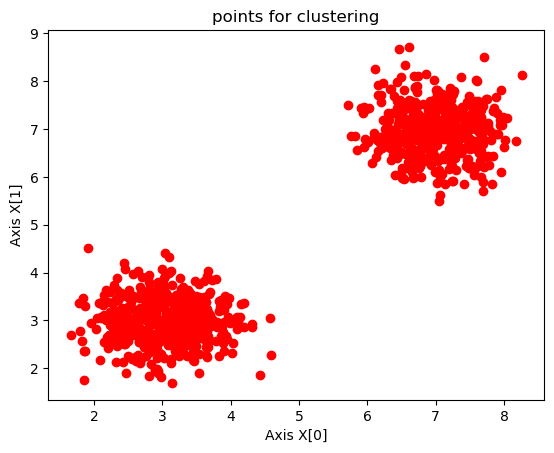

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import OPTICS
import numpy as np
import matplotlib.pyplot as plt

# Configuration options
num_samples_total = 1000
cluster_centers = [(3,3), (7,7)]

num_classes = 2

# Generate data
X, y = make_blobs(n_samples = num_samples_total, centers = cluster_centers, n_features = num_classes, center_box=(0, 1), cluster_std = 0.5)

plt.scatter(X[:,0], X[:,1], c='red', marker="o", picker=True)
plt.title(f'points for clustering')
plt.xlabel('Axis X[0]')
plt.ylabel('Axis X[1]')
plt.show()

Vamos a aplicar el algoritmo OPTICS implementado en scikit
Consulta en la ayuda online de scikit los parámetros que estamos usando en OPTICS y escribe lo que significan en la siguiente caja. Presta especial atencion al parámetro 'xi'. Consulta lo que significa.
Explica lo que devuelve esta implementación del algoritmo.

**Respuesta:** labels -> Vector con las etiquetas asignadas a cada punto.
reachability -> Distancia mínima para alcanzar cada punto desde un punto más cercano con densidad suficiente. Representa la "densidad local".
ordering -> Orden en el que los puntos fueron visitados, útil para graficar la curva de reachability.
core_distances -> Distancia mínima que un punto necesita para ser considerado núcleo (core point).
predecessor -> Índice del punto anterior en el orden de recorrido.

¿Con qué valor etiqueta OPTICS los puntos ruido?
**Respuesta:** OPTICS etiqueta los puntos considerados ruido con el valor -1 en el vector labels_

Estimated no. of clusters: 2
Estimated no. of noise points: 0
[0 1 1 1 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 0 1
 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 1 0 0 1 0 1 1 0 1 1 1 1 0 1 0 0 0 1 0 1 1
 0 0 1 1 1 1 0 1 1 1 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1
 1 0 1 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1
 0 1 1 1 1 0 1 1 1 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0
 0 1 1 1 0 1 0 0 0 0 1 0 1 1 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1
 0 1 0 1 0 1 0 1 1 0 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1
 1 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 0 0 0 1 0 0
 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0
 1 0 1 1 1 1 0 0 0 0 0 1 0 1 0 1 1 1 1 0 0 0 1 1 1 1 0 1 1 0 0 1 0 1 0 0 1
 1 0 1 0 1 1 0 1 0 0 1 0 0 0 1 0 1 1 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 0 1 1 1
 1 0 0 1 0 0 0 1 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 1 1 0
 0 0 1 0 1 0 1 0 0 0 1 1 1 0 1 0 1 0 1

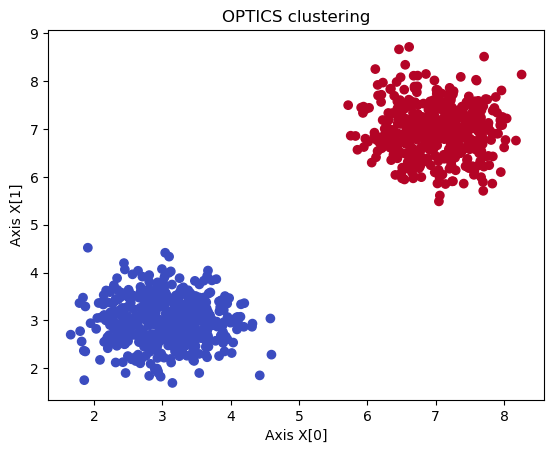

In [9]:
#configuration parameters
num_classes = len(cluster_centers)

cluster_method = 'xi'
metric = 'minkowski'

epsilon = 0.8
min_samples = 10

# Compute OPTICS
db = OPTICS(max_eps=epsilon, min_samples=min_samples, cluster_method=cluster_method, metric=metric, xi=0.5).fit(X)
labels = db.labels_

no_clusters = len(np.unique(labels) )
no_noise = np.sum(np.array(labels) == -1, axis=0)

print('Estimated no. of clusters: %d' % no_clusters)
print('Estimated no. of noise points: %d' % no_noise)
print(labels)

# Generate scatter plot for training data
colors = list(map(lambda x: '#3b4cc0' if x == 1 else '#b40426' , labels))
plt.scatter(X[:,0], X[:,1], c=colors, marker="o", picker=True)
plt.title(f'OPTICS clustering')
plt.xlabel('Axis X[0]')
plt.ylabel('Axis X[1]')
plt.show()

Prueba ahora con otros valores de epsilon (más bajos como 3.0 1.0, 0.8) y observa que el algoritmo proporciona los mismos agrupamientos. 

Modifica también el parámetro MinPts. ¿Es igual de robusto el algoritmo a este parámetro a aumento de valor, descenso de valor o a ambos? Razona tus resultados

**Respuesta** 
Epsilon: tiene una robustez alta, mientras que no sea muy pequeño. Limita la distancia máxima entre vecinos.
min_samples:	tiene una robustez Media-Baja, controla la densidad mínima por lo que si se sube, aparecen más puntos ruido; si se baja, los clústeres se unen

Vamos a representar ahora el diagrama de distancias de alcance. Para ello debemos combinar dos métodos: aquel que nos muestra las distancias de alcance para cada punto de un cluster y aquel que nos ordena estas distancias.

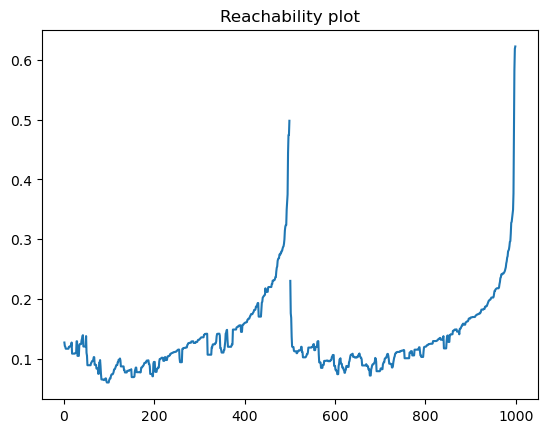

In [10]:
# Generate reachability plot
reachability = db.reachability_[db.ordering_]
plt.plot(reachability)
plt.title('Reachability plot')
plt.show()

Interpreta el diagrama de alcances que te sale.

**Escribe tu respuesta aquí:**
Se aprecian dos “valles” bien definidos, separados por picos pronunciados, el primer valle (izquierda) muestra valores de alcance bajos y estables, indicando un primer clúster denso. El segundo valle (derecha) también mantiene valores bajos, representando un segundo clúster.
Entre ambos valles hay un pico grande de reachability, que marca una transición de baja densidad, ahí es donde el algoritmo detecta la frontera entre los dos clústeres.
En los extremos (finales del eje X), las distancias aumentan notablemente, lo que corresponde a puntos más aislados o ruido.